In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/sleep_edf_raw/

SC4122E0-PSG.edf	SC4172E0-PSG.edf	SC4221E0-PSG.edf
SC4122EV-Hypnogram.edf	SC4172EC-Hypnogram.edf	SC4221EJ-Hypnogram.edf
SC4141E0-PSG.edf	SC4181E0-PSG.edf	SC4222E0-PSG.edf
SC4141EU-Hypnogram.edf	SC4181EC-Hypnogram.edf	SC4222EC-Hypnogram.edf
SC4142E0-PSG.edf	SC4182E0-PSG.edf	SC4231E0-PSG.edf
SC4142EU-Hypnogram.edf	SC4182EC-Hypnogram.edf	SC4231EJ-Hypnogram.edf
SC4151E0-PSG.edf	SC4191E0-PSG.edf	SC4232E0-PSG.edf
SC4151EC-Hypnogram.edf	SC4191EP-Hypnogram.edf	SC4232EV-Hypnogram.edf
SC4152E0-PSG.edf	SC4192E0-PSG.edf	SC4241E0-PSG.edf
SC4152EC-Hypnogram.edf	SC4192EV-Hypnogram.edf	SC4241EC-Hypnogram.edf
SC4161E0-PSG.edf	SC4202E0-PSG.edf	SC4242E0-PSG.edf
SC4161EC-Hypnogram.edf	SC4202EC-Hypnogram.edf	SC4242EA-Hypnogram.edf
SC4162E0-PSG.edf	SC4211E0-PSG.edf	SC4351F0-PSG.edf
SC4162EC-Hypnogram.edf	SC4211EC-Hypnogram.edf	SC4351FA-Hypnogram.edf
SC4171E0-PSG.edf	SC4212E0-PSG.edf	SC4352F0-PSG.edf
SC4171EU-Hypnogram.edf	SC4212EC-Hypnogram.edf	SC4352FV-Hypnogram.edf


In [ ]:
EEG_CHANNEL = "Fpz-Cz"
SFREQ = 100
EPOCH_SEC = 30

RAW_DIR = "/content/drive/MyDrive/sleep_edf_raw"
OUT_DIR = "/content/drive/MyDrive/sleep_edf_processed"

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 63.5 MB/s eta 0:00:00


In [ ]:
import os

RAW_DIR = "/content/drive/MyDrive/sleep_edf_raw"

psg_files = [f for f in os.listdir(RAW_DIR) if "PSG" in f]
hyp_files = [f for f in os.listdir(RAW_DIR) if "Hypnogram" in f]

print("PSG:", len(psg_files))
print("HYP:", len(hyp_files))

PSG: 24
HYP: 24


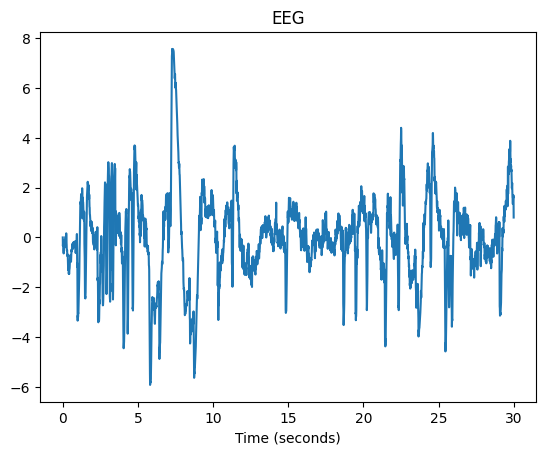

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

SUBJECT_DIR = "/content/drive/MyDrive/sleep_edf_processed/SC4001E"

X = np.load(os.path.join(SUBJECT_DIR, "X.npy"))

idx = 0

signal = X[idx][0]          # one channel
time = np.arange(len(signal)) / 100  # match signal length

plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.title("EEG")
plt.show()


In [ ]:
def get_recording_key(filename):
    """
    Extract subject + night key like SC4001E0
    """
    return filename[:7]   # SC4001E0

In [ ]:
pairs = []

for psg in psg_files:
    psg_key = get_recording_key(psg)

    # find matching hypnogram
    matches = [
        h for h in hyp_files
        if h.startswith(psg_key)
    ]

    if len(matches) == 1:
        pairs.append((psg, matches[0]))
    else:
        print("No or multiple matches for:", psg)

In [ ]:
print("Total valid pairs:", len(pairs))
for p in pairs[:5]:
    print(p)

Total valid pairs: 24
('SC4122E0-PSG.edf', 'SC4122EV-Hypnogram.edf')
('SC4151E0-PSG.edf', 'SC4151EC-Hypnogram.edf')
('SC4142E0-PSG.edf', 'SC4142EU-Hypnogram.edf')
('SC4141E0-PSG.edf', 'SC4141EU-Hypnogram.edf')
('SC4152E0-PSG.edf', 'SC4152EC-Hypnogram.edf')


In [ ]:
import mne
import numpy as np

OUT_DIR = "/content/drive/MyDrive/sleep_edf_processed"
os.makedirs(OUT_DIR, exist_ok=True)

for psg_file, hyp_file in pairs:
    record_id = get_recording_key(psg_file)  # e.g., SC4001E0
    print("Processing:", record_id)

    psg_path = f"{RAW_DIR}/{psg_file}"
    hyp_path = f"{RAW_DIR}/{hyp_file}"

    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    annot = mne.read_annotations(hyp_path)
    raw.set_annotations(annot)

    # pick EEG
    raw.pick_channels(["EEG Fpz-Cz", "EEG Pz-Oz"])
    raw.filter(0.3, 35)
    raw.resample(100)

    events, event_id = mne.events_from_annotations(raw)

    epochs = mne.Epochs(
        raw, events, event_id,
        tmin=0, tmax=30,
        baseline=None,
        preload=True,
        verbose=False
    )

    label_map = {
        "Sleep stage W": 0,
        "Sleep stage 1": 1,
        "Sleep stage 2": 2,
        "Sleep stage 3": 3,
        "Sleep stage 4": 3,
        "Sleep stage R": 4
    }

    X, y = [], []

    for ep, ev in zip(epochs.get_data(), epochs.events[:, -1]):
        stage = [k for k, v in event_id.items() if v == ev][0]
        if stage in label_map:
            X.append(ep)
            y.append(label_map[stage])

    X = np.array(X)
    y = np.array(y)

    # normalize per recording
    X = (X - X.mean()) / X.std()

    out_path = f"{OUT_DIR}/{record_id}"
    os.makedirs(out_path, exist_ok=True)

    np.save(f"{out_path}/X.npy", X)
    np.save(f"{out_path}/y.npy", y)

    print("Saved:", record_id, X.shape)

Processing: SC4122E


/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_3895/3151229111.py:16: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1101 samples (11.010 s)

Sampling frequency of the instance is already 100.0, returning unmodified.
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Saved: SC4122E (149, 2, 3001)
Processing: SC4151E


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1101 samples (11.010 s)

Sampling frequency of the instance is already 100.0, returning unmodified.
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Saved: SC4351F (152, 2, 3001)
Processing: SC4352F


/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_3895/3151229111.py:14: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_3895/3151229111.py:16: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1101 samples (11.010 s)

Sampling frequency of the instance is already 100.0, returning unmodified.
Used Annotations descriptions: [np.str_('Movement time'), np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Saved: SC4352F (147, 2, 3001)


In [ ]:
!ls /content/drive/MyDrive/sleep_edf_processed | wc -l

49


In [ ]:
import numpy as np

X = np.load("/content/drive/MyDrive/sleep_edf_processed/SC4001E/X.npy")
y = np.load("/content/drive/MyDrive/sleep_edf_processed/SC4001E/y.npy")

print(X.shape, y.shape, set(y))

(153, 2, 3001) (153,) {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}


In [ ]:
import numpy as np
print(dict(zip(*np.unique(y, return_counts=True))))

{np.int64(0): np.int64(12), np.int64(1): np.int64(24), np.int64(2): np.int64(40), np.int64(3): np.int64(71), np.int64(4): np.int64(6)}


In [ ]:
#lstm
import torch
OUT_DIR = "/content/drive/MyDrive/sleep_edf_processed"
class SleepDataset(torch.utils.data.Dataset):
    def __init__(self, subject_dirs):
        self.samples = []
        for d in subject_dirs:
            X = np.load(f"{d}/X.npy")
            y = np.load(f"{d}/y.npy")
            for i in range(len(y)):
                self.samples.append((X[i], y[i]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long)
        )


In [ ]:
import glob
OUT_DIR = "/content/drive/MyDrive/sleep_edf_processed"
subjects = sorted(glob.glob(f"{OUT_DIR}/*"))
print("Total subjects:", len(subjects))
train_dirs = subjects[:14]
val_dirs   = subjects[14:17]
test_dirs  = subjects[17:]

Total subjects: 49


In [ ]:
#LSTM
train_loader = torch.utils.data.DataLoader(
    SleepDataset(train_dirs), batch_size=32, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    SleepDataset(val_dirs), batch_size=32
)

test_loader = torch.utils.data.DataLoader(
    SleepDataset(test_dirs), batch_size=32
)

In [ ]:
#lstm
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=50, stride=6),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(64, 128, kernel_size=8),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )

        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.fc = nn.Sequential(
          nn.Dropout(0.3),
          nn.Linear(128, 5)
      )
    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

In [ ]:
#cnn
def compute_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
#cnn
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

all_y = []
for d in train_dirs:
    all_y.extend(np.load(f"{d}/y.npy"))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_y),
    y=all_y
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(class_weights)

tensor([1.7453, 0.8573, 0.6585, 0.7722, 2.2368], device='cuda:0')


In [ ]:
#cnn
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_accs = []
val_accs = []

EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Accuracy calculation
    train_acc = compute_accuracy(model, train_loader, device)
    val_acc   = compute_accuracy(model, val_loader, device)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss:.3f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/25 | Loss: 80.399 | Train Acc: 0.6326 | Val Acc: 0.6336
Epoch 2/25 | Loss: 57.266 | Train Acc: 0.6634 | Val Acc: 0.6705
Epoch 3/25 | Loss: 54.091 | Train Acc: 0.6357 | Val Acc: 0.6866
Epoch 4/25 | Loss: 48.348 | Train Acc: 0.6470 | Val Acc: 0.6613
Epoch 5/25 | Loss: 49.565 | Train Acc: 0.6927 | Val Acc: 0.6682
Epoch 6/25 | Loss: 47.591 | Train Acc: 0.6459 | Val Acc: 0.5484
Epoch 7/25 | Loss: 46.360 | Train Acc: 0.6444 | Val Acc: 0.5599
Epoch 8/25 | Loss: 43.795 | Train Acc: 0.7009 | Val Acc: 0.6313
Epoch 9/25 | Loss: 42.354 | Train Acc: 0.6670 | Val Acc: 0.6866
Epoch 10/25 | Loss: 43.733 | Train Acc: 0.7091 | Val Acc: 0.6774
Epoch 11/25 | Loss: 40.906 | Train Acc: 0.6994 | Val Acc: 0.6290
Epoch 12/25 | Loss: 41.012 | Train Acc: 0.7431 | Val Acc: 0.6982
Epoch 13/25 | Loss: 37.576 | Train Acc: 0.7718 | Val Acc: 0.7419
Epoch 14/25 | Loss: 38.340 | Train Acc: 0.7580 | Val Acc: 0.6959
Epoch 15/25 | Loss: 35.722 | Train Acc: 0.7821 | Val Acc: 0.7488
Epoch 16/25 | Loss: 36.456 | Train

In [ ]:
#cnn
import numpy as np

best_epoch = np.argmax(val_accs)

print("Best Epoch:", best_epoch + 1)
print(f"Best Training Accuracy   : {train_accs[best_epoch]:.4f}")
print(f"Best Validation Accuracy : {val_accs[best_epoch]:.4f}")

Best Epoch: 15
Best Training Accuracy   : 0.7821
Best Validation Accuracy : 0.7488


In [ ]:
#cnn
test_acc = compute_accuracy(model, test_loader, device)
print(f"Overall Test Accuracy: {test_acc:.4f}")

Overall Test Accuracy: 0.7134


In [ ]:
#cnn
print("Final Training Accuracy :", compute_accuracy(model, train_loader, device))
print("Final Validation Accuracy:", compute_accuracy(model, val_loader, device))
print("Final Test Accuracy     :", compute_accuracy(model, test_loader, device))

Final Training Accuracy : 0.7857142857142857
Final Validation Accuracy: 0.6497695852534562
Final Test Accuracy     : 0.7133550488599348


In [ ]:
#cnn
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73       168
           1       0.55      0.55      0.55       260
           2       0.76      0.61      0.68       503
           3       0.84      0.89      0.86       507
           4       0.44      0.64      0.52        97

    accuracy                           0.71      1535
   macro avg       0.66      0.69      0.67      1535
weighted avg       0.72      0.71      0.71      1535



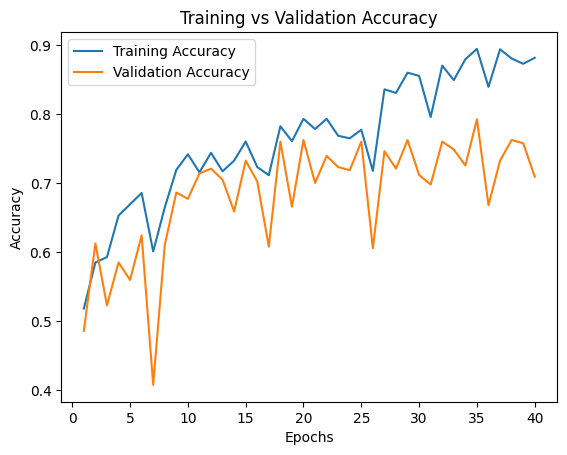

In [ ]:
#cnn
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

In [ ]:
#tranformer
import torch
import numpy as np
OUT_DIR = "/content/drive/MyDrive/sleep_edf_processed"
class SleepDataset(torch.utils.data.Dataset):

    def __init__(self, subject_dirs, context=5):

        self.samples = []
        half = context // 2

        for d in subject_dirs:

            X = np.load(f"{d}/X.npy")
            y = np.load(f"{d}/y.npy")

            if len(y) < context:
                continue

            for i in range(half, len(y)-half):
                seq = X[i-half : i+half+1]
                label = y[i]

                self.samples.append((seq, label))

        print("Total samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        x, y = self.samples[idx]

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long)
          )

In [ ]:
#transformers
train_loader = torch.utils.data.DataLoader(
    SleepDataset(train_dirs, context=5),
    batch_size=32,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    SleepDataset(val_dirs, context=5),
    batch_size=32
)

test_loader = torch.utils.data.DataLoader(
    SleepDataset(test_dirs, context=5),
    batch_size=32
)

Total samples: 1890
Total samples: 422
Total samples: 3949


In [ ]:
#transformer
import math
import torch.nn as nn
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=50):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [ ]:
#transformer
class CNNEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(2,64,50,stride=6),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(8),

            nn.Conv1d(64,256,8),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.AdaptiveAvgPool1d(50)
        )

    def forward(self,x):

        x = self.net(x)

        x = x.mean(dim=2)

        return x

In [ ]:
#transformer
class SleepTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = CNNEncoder()

        self.pos = PositionalEncoding(256)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            dropout=0.2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.fc = nn.Sequential(
            nn.LayerNorm(256),
            nn.Dropout(0.5),
            nn.Linear(256,5)
        )

    def forward(self,x):
        B,T,C,L = x.shape
        x = x.view(B*T, C, L)
        feats = self.encoder(x)
        feats = feats.view(B,T,-1)
        feats = self.pos(feats)
        feats = self.transformer(feats)
        feats = feats.mean(dim=1)
        return self.fc(feats)

In [ ]:
#tranformer
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
all_y = []

for d in train_dirs:
    y = np.load(f"{d}/y.npy")
    all_y.extend(y)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_y),
    y=all_y
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class weights: tensor([1.7453, 0.8573, 0.6585, 0.7722, 2.2368], device='cuda:0')


In [ ]:
#transformer
def compute_accuracy(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    accuracy = correct / total

    return accuracy

In [ ]:
#tranformer
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 40
model = SleepTransformer().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    train_acc = compute_accuracy(model, train_loader, device)
    val_acc   = compute_accuracy(model, val_loader, device)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss:.3f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/40 | Loss: 84.774 | Train Acc: 0.3825 | Val Acc: 0.4242
Epoch 2/40 | Loss: 77.481 | Train Acc: 0.4048 | Val Acc: 0.4905
Epoch 3/40 | Loss: 74.386 | Train Acc: 0.4243 | Val Acc: 0.5142
Epoch 4/40 | Loss: 70.767 | Train Acc: 0.4529 | Val Acc: 0.5450
Epoch 5/40 | Loss: 66.734 | Train Acc: 0.5788 | Val Acc: 0.6256
Epoch 6/40 | Loss: 53.639 | Train Acc: 0.5429 | Val Acc: 0.5071
Epoch 7/40 | Loss: 45.047 | Train Acc: 0.6926 | Val Acc: 0.7180
Epoch 8/40 | Loss: 41.025 | Train Acc: 0.8169 | Val Acc: 0.7488
Epoch 9/40 | Loss: 37.581 | Train Acc: 0.8016 | Val Acc: 0.7773
Epoch 10/40 | Loss: 32.745 | Train Acc: 0.7815 | Val Acc: 0.7133
Epoch 11/40 | Loss: 30.175 | Train Acc: 0.8032 | Val Acc: 0.7441
Epoch 12/40 | Loss: 28.979 | Train Acc: 0.8709 | Val Acc: 0.7133
Epoch 13/40 | Loss: 26.181 | Train Acc: 0.7762 | Val Acc: 0.6493
Epoch 14/40 | Loss: 23.295 | Train Acc: 0.9058 | Val Acc: 0.7180
Epoch 15/40 | Loss: 20.782 | Train Acc: 0.9190 | Val Acc: 0.7820
Epoch 16/40 | Loss: 17.515 | Train

In [ ]:
#transformers
print("Final Training Accuracy :", compute_accuracy(model, train_loader, device))
print("Final Validation Accuracy:", compute_accuracy(model, val_loader, device))
print("Final Test Accuracy     :", compute_accuracy(model, test_loader, device))

Final Training Accuracy : 1.0
Final Validation Accuracy: 0.7796208530805687
Final Test Accuracy     : 0.7348695872372752


In [ ]:
#transformers
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.60      0.70       437
           1       0.58      0.71      0.64       709
           2       0.73      0.75      0.74      1327
           3       0.86      0.84      0.85      1215
           4       0.59      0.43      0.50       261

    accuracy                           0.73      3949
   macro avg       0.72      0.67      0.68      3949
weighted avg       0.74      0.73      0.73      3949



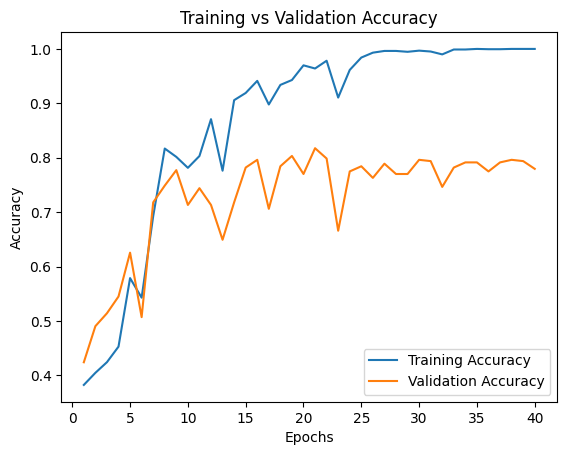

In [ ]:
#transformers
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()